# Tests for `calculate_native_gradient_tracer`

This notebook demonstrates the tests in
`tests/test_native_gradient_tracer.py` for
`dbof.utils.native_gradient.calculate_native_gradient_tracer`, which
computes the gradient *vector* of a scalar tracer on the native LLC
grid: model-x/-y finite differences, interpolate to centres, then
rotate the gradient into geographic axes with
`R = [[CS,-SN],[SN,CS]]`.

For a linear tracer `s = p·x + q·y` the model gradient is exactly
`(p, q)`, so the rotated result is the closed form
`(p·CS − q·SN, p·SN + q·CS)`. Two structural facts (demonstrated
below on the real grid): a **constant tracer gives an exactly zero
gradient** (differencing happens before rotation), and the
**gradient magnitude is exactly rotation-invariant** (`|R·g| = |g|`).

All figures are generated from the test code (offline synthetic +
online real-grid).

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We reuse the test module itself so
# the figures are built from the exact fixtures, helpers and assertions in
# tests/test_native_gradient_tracer.py.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm

import dbof.utils.native_gradient as ng

_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_native_gradient_tracer as tgt  # noqa: E402

print('EDGE_MARGIN =', tgt.EDGE_MARGIN, '| N_FACES =', tgt.N_FACES)
print('tracer cache:', tgt.REAL_TRACER_CACHE)


EDGE_MARGIN = 3 | N_FACES = 13
tracer cache: /tmp/llc4320_tracer_Theta.nc


## 1. Offline: linear tracer, gradient components vs analytic

Synthetic 13-face grid with a 45° rotation and `s = p·x + q·y`.
Each returned component is constant over the face interior (dashed
box) and equals the analytic rotated gradient `R·(p,q)`.

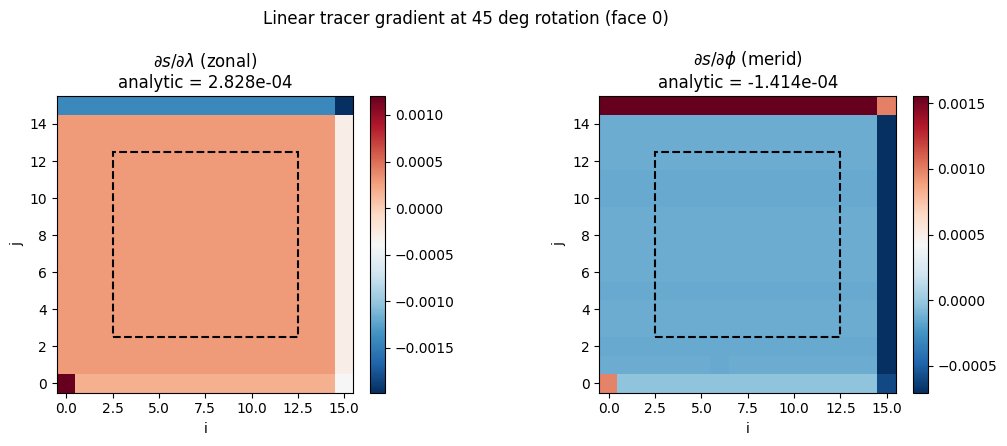

interior zonal err = 1.08e-19, merid err = 1.08e-19


In [2]:
d = 2500.0
p, q = 1.0e-4, -3.0e-4
alpha = np.radians(45.0)
cs, sn = np.cos(alpha), np.sin(alpha)
ds, grid = tgt.make_synthetic_grid(n=16, d=d, cs=cs, sn=sn)
s = tgt.add_linear_tracer(ds, d, p, q)
glam, gphi = ng.calculate_native_gradient_tracer(s, ds, grid)
t_lam, t_phi = tgt.analytic_rotated_gradient(p, q, cs, sn)

m = tgt.EDGE_MARGIN
n = ds.sizes['i']
comps = [(glam, t_lam, r'$\partial s/\partial \lambda$ (zonal)'),
         (gphi, t_phi, r'$\partial s/\partial \phi$ (merid)')]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (da, target, lab) in zip(axes, comps):
    pcm = ax.imshow(da.isel(face=0).values, origin='lower', cmap='RdBu_r')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.add_patch(Rectangle((m - 0.5, m - 0.5), n - 2 * m, n - 2 * m,
                           fill=False, ec='k', ls='--', lw=1.5))
    ax.set_title('%s\nanalytic = %.3e' % (lab, target))
    ax.set_xlabel('i'); ax.set_ylabel('j')
fig.suptitle('Linear tracer gradient at 45 deg rotation (face 0)')
fig.tight_layout(); plt.show()
print('interior zonal err = %.2e, merid err = %.2e'
      % (np.abs(tgt.interior(glam).values - t_lam).max(),
         np.abs(tgt.interior(gphi).values - t_phi).max()))


## 2. Offline: components track `R·(p,q)` across angles

Sweeping the grid rotation, the computed interior means (markers)
lie exactly on the analytic curves — the sign conventions are
correct at every angle (this is the parametrized test).

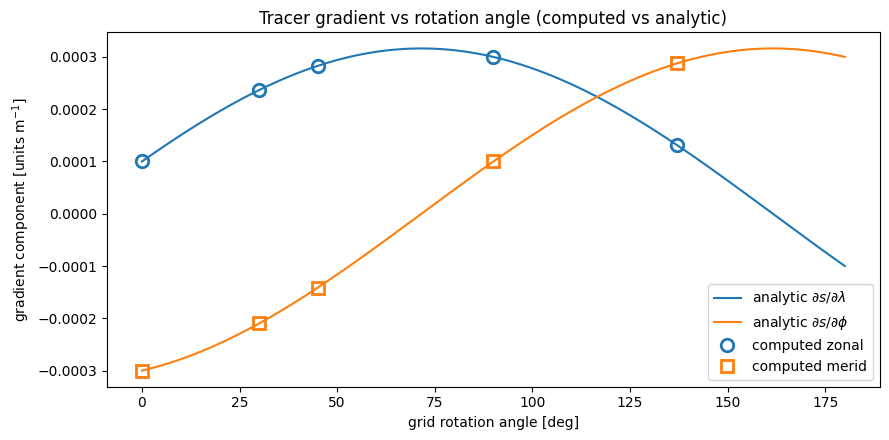

In [3]:
angles = [0.0, 30.0, 45.0, 90.0, 137.0]
comp_lam, comp_phi = [], []
for deg in angles:
    c, sdeg = np.cos(np.radians(deg)), np.sin(np.radians(deg))
    dsa, ga = tgt.make_synthetic_grid(n=16, d=d, cs=c, sn=sdeg)
    sa = tgt.add_linear_tracer(dsa, d, p, q)
    gl, gp = ng.calculate_native_gradient_tracer(sa, dsa, ga)
    comp_lam.append(float(tgt.interior(gl).values.mean()))
    comp_phi.append(float(tgt.interior(gp).values.mean()))

fine = np.linspace(0, 180, 181)
cf, sf = np.cos(np.radians(fine)), np.sin(np.radians(fine))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fine, p * cf - q * sf, 'C0-', label=r'analytic $\partial s/\partial\lambda$')
ax.plot(fine, p * sf + q * cf, 'C1-', label=r'analytic $\partial s/\partial\phi$')
ax.plot(angles, comp_lam, 'C0o', ms=9, mfc='none', mew=2, label='computed zonal')
ax.plot(angles, comp_phi, 'C1s', ms=9, mfc='none', mew=2, label='computed merid')
ax.set_xlabel('grid rotation angle [deg]')
ax.set_ylabel('gradient component [units m$^{-1}$]')
ax.set_title('Tracer gradient vs rotation angle (computed vs analytic)')
ax.legend(); fig.tight_layout(); plt.show()


## 3. Online: real SST (Theta) gradient on the LLC4320 grid

Magnitude of the geographic-frame SST gradient on one face
(downsampled, land-masked, log scale) — the ocean fronts. Reuses
the cached real grid and the OSN surface Theta.

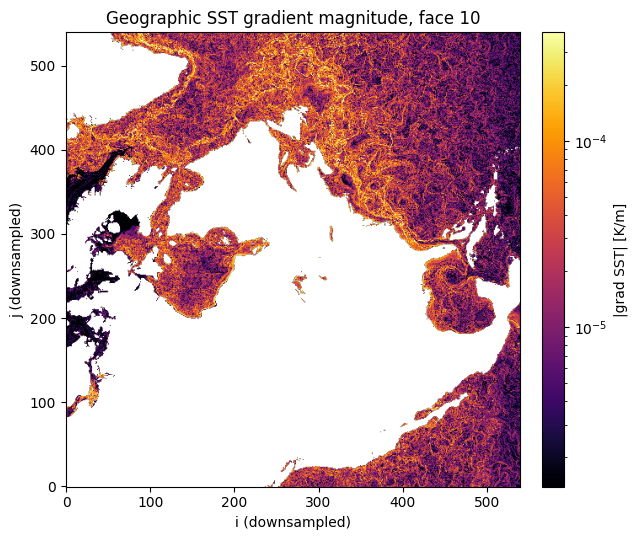

In [4]:
gr = tgt.load_real_llc_grid()
grid_r = tgt.set_xgcm_grid(gr.drop_vars('hFacC'), use_connections=True)
theta = tgt.load_real_llc_surface_tracer()
theta = theta.assign_coords(
    {c: gr.coords[c] for c in theta.dims if c in gr.coords})
gx_g, gy_g = ng.calculate_native_gradient_tracer(theta, gr, grid_r)
gx_m, gy_m = tgt.model_frame_gradient(theta, gr, grid_r)
mag_g = np.sqrt(gx_g ** 2 + gy_g ** 2)
mag_m = np.sqrt(gx_m ** 2 + gy_m ** 2)

FACE, stride = 10, 8
def fmap(da):
    a = da.isel(face=FACE).values[::stride, ::stride]
    lm = gr['hFacC'].isel(face=FACE).values[::stride, ::stride] > 0
    return np.where(lm & (a > 0), a, np.nan)
img = fmap(mag_g)
pos = img[np.isfinite(img)]
fig, ax = plt.subplots(figsize=(6.5, 5.5))
pcm = ax.imshow(img, origin='lower', cmap='inferno',
                norm=LogNorm(vmin=np.nanpercentile(pos, 5),
                             vmax=np.nanpercentile(pos, 99.5)))
fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04, label='|grad SST| [K/m]')
ax.set_title('Geographic SST gradient magnitude, face %d' % FACE)
ax.set_xlabel('i (downsampled)'); ax.set_ylabel('j (downsampled)')
fig.tight_layout(); plt.show()


## 4. Online: gradient magnitude is rotation-invariant

`|grad_geographic|` vs `|grad_model|` for sampled ocean points lie
on `y = x`, and the difference is at float32 machine precision —
the magnitude is preserved exactly because the rotation acts on the
already-computed gradient (this is the online invariance test).

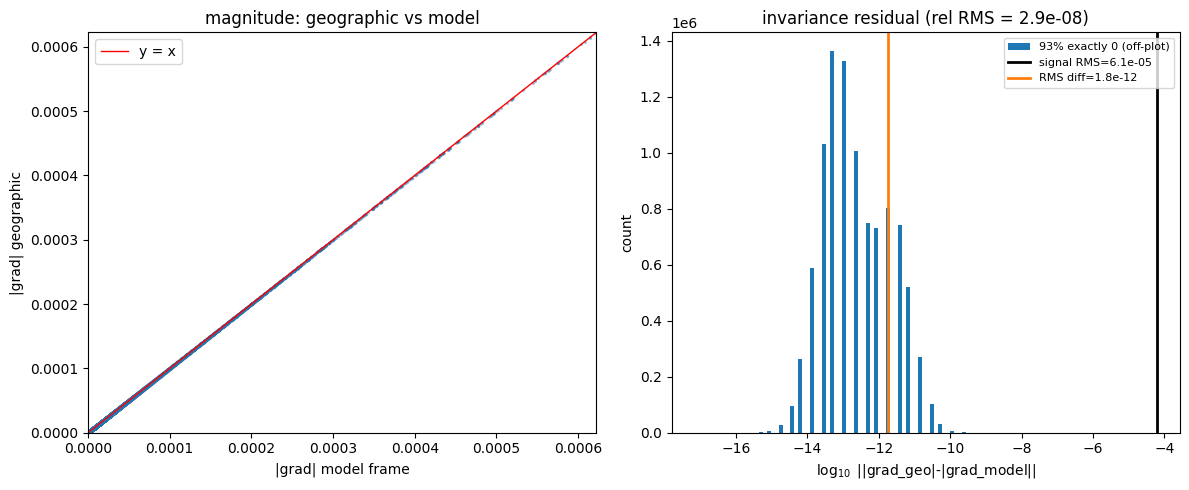

In [5]:
ocean = tgt.interior(gr['hFacC']).values > 0
g = tgt.interior(mag_g).values[ocean]
mm = tgt.interior(mag_m).values[ocean]
fin = np.isfinite(g) & np.isfinite(mm); g, mm = g[fin], mm[fin]
d = np.abs(g - mm).astype('float64')
srms = np.sqrt(np.mean(mm ** 2)); drms = np.sqrt(np.mean(d ** 2))

rng = np.random.default_rng(0)
idx = rng.choice(g.size, size=min(40000, g.size), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(mm[idx], g[idx], s=2, alpha=0.3)
lim = np.nanpercentile(mm, 99.9)
axes[0].plot([0, lim], [0, lim], 'r-', lw=1, label='y = x')
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('|grad| model frame'); axes[0].set_ylabel('|grad| geographic')
axes[0].set_title('magnitude: geographic vs model'); axes[0].legend()

zero_frac = np.mean(d == 0.0)
dpos = d[d > 0]
axes[1].hist(np.log10(dpos), bins=70,
             label=f'{zero_frac:.0%} exactly 0 (off-plot)')
axes[1].axvline(np.log10(srms), color='k', lw=2, label=f'signal RMS={srms:.1e}')
axes[1].axvline(np.log10(drms), color='C1', lw=2, label=f'RMS diff={drms:.1e}')
axes[1].set_xlabel(r'$\log_{10}$ ||grad_geo|-|grad_model||')
axes[1].set_ylabel('count')
axes[1].set_title(f'invariance residual (rel RMS = {drms / srms:.1e})')
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


## 5. Run the test suite

Call the offline tests directly, and the online tests with the
network gate enabled (caches already present). No exception means
they pass.

In [6]:
import os
tgt.test_tracer_no_rotation_recovers_model_gradient()
tgt.test_tracer_90deg_rotation_sign_conventions()
tgt.test_tracer_constant_field_zero_gradient()
for a in [0.0, 30.0, 45.0, 90.0, 137.0]:
    tgt.test_tracer_general_angle_matches_rotation(a)
tgt.test_tracer_output_coordinate_contract()
print('offline tests passed.')

os.environ['RUN_LLC_NETWORK_TESTS'] = '1'  # caches already present
tgt.test_tracer_real_grid_constant_field_zero_gradient()
tgt.test_tracer_real_grid_gradient_magnitude_invariance()
print('online tests passed.')


offline tests passed.


online tests passed.
